# DAF Analysis — Swell Conditions

Individual and system mooring/fender DAF for each swell condition (65 Hs–Tp combinations),
plotted on Hs–Tp scatters with dots coloured by DAF.

Individual plots annotate each circle with the governing element number (mooring line 1–8 or fender 1–6).

Headings: 0°, 45°, 90°, 135°, 180°.

In [ ]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from pathlib import Path

# Resolve this notebook's folder (works in VS Code and standard Jupyter)
NOTEBOOK_DIR = Path(globals().get('__vsc_ipynb_file__', Path.cwd() / '_')).parent
os.chdir(NOTEBOOK_DIR)
import sys
sys.path.insert(0, str(NOTEBOOK_DIR))
from thesis_style import apply, full, save
apply()
print(f'Working directory: {Path.cwd()}')

In [2]:
TRANSIENT_S         = 400
DT                  = 0.5
TRANSIENT_IDX       = int(TRANSIENT_S / DT)
STATIC_THRESHOLD_KN = 1.0   # fenders below this static force are excluded

MOORING_ELEMS = [f'Mooring{i}' for i in range(1, 9)]
FENDER_ELEMS  = [f'Fender{i}'  for i in range(1, 7)]

HEADINGS = {
    '0deg'  : {'label': '0°',   'static': '0deg/Swells/StaticResults_swells.h5',
                'dynamic': '0deg/Swells/DynamicResults_swells.h5'},
    '45deg' : {'label': '45°',  'static': '45deg/Swells/StaticResults_swells.h5',
                'dynamic': '45deg/Swells/DynamicResults_swells.h5'},
    '90deg' : {'label': '90°',  'static': '90deg/Swells/StaticResults_swells.h5',
                'dynamic': '90deg/Swells/DynamicResults_swells.h5'},
    '135deg': {'label': '135°', 'static': '135deg/Swells/StaticResults_swells.h5',
                'dynamic': '135deg/Swells/DynamicResults_swells.h5'},
    '180deg': {'label': '180°', 'static': '180deg/Swells/StaticResults_swells.h5',
                'dynamic': '180deg/Swells/DynamicResults_swells.h5'},
}

MOORING_VMIN, MOORING_VMAX = 1.0, 2.0
FENDER_VMIN,  FENDER_VMAX  = 1.0, 2.0

In [3]:
HS_VALS = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]
TP_VALS = list(range(8, 21))

cases = pd.DataFrame(
    [(hs, tp) for hs in HS_VALS for tp in TP_VALS],
    columns=['Hs', 'Tp']
)
cases.insert(0, 'condition', cases.index + 1)
print(f'Generated {len(cases)} swell conditions')
print(cases.to_string(index=False))

Generated 78 swell conditions
 condition  Hs  Tp
         1 0.1   8
         2 0.1   9
         3 0.1  10
         4 0.1  11
         5 0.1  12
         6 0.1  13
         7 0.1  14
         8 0.1  15
         9 0.1  16
        10 0.1  17
        11 0.1  18
        12 0.1  19
        13 0.1  20
        14 0.2   8
        15 0.2   9
        16 0.2  10
        17 0.2  11
        18 0.2  12
        19 0.2  13
        20 0.2  14
        21 0.2  15
        22 0.2  16
        23 0.2  17
        24 0.2  18
        25 0.2  19
        26 0.2  20
        27 0.4   8
        28 0.4   9
        29 0.4  10
        30 0.4  11
        31 0.4  12
        32 0.4  13
        33 0.4  14
        34 0.4  15
        35 0.4  16
        36 0.4  17
        37 0.4  18
        38 0.4  19
        39 0.4  20
        40 0.6   8
        41 0.6   9
        42 0.6  10
        43 0.6  11
        44 0.6  12
        45 0.6  13
        46 0.6  14
        47 0.6  15
        48 0.6  16
        49 0.6  17
        50 0.6  18
 

In [4]:
def load_swell_daf(heading_key):
    cfg          = HEADINGS[heading_key]
    static_path  = NOTEBOOK_DIR / cfg['static']
    dynamic_path = NOTEBOOK_DIR / cfg['dynamic']

    if not static_path.exists() or not dynamic_path.exists():
        return None

    records = []
    try:
        with h5py.File(static_path, 'r') as sf, h5py.File(dynamic_path, 'r') as dfh:
            root_s = list(sf.keys())[0]
            root_d = list(dfh.keys())[0]
            sw_s   = sf[root_s]['Swells']
            sw_d   = dfh[root_d]['Swells']

            # robust: extract trailing number after last underscore (handles any prefix)
            keys = sorted(sw_s.keys(), key=lambda x: int(x.rsplit('_', 1)[-1]))
            for k in keys:
                n = int(k.rsplit('_', 1)[-1])
                try:
                    grp_s = sw_s[k]['Static']['Tanker']
                    grp_d = sw_d[k]['Dynamic']['Tanker']['Positioning system force']
                except KeyError as e:
                    print(f'  WARNING: {heading_key} condition {n} missing key {e} — skipped')
                    continue

                # Mooring system DAF
                static_m    = sum(float(grp_s[m]['FTotal'][()]) for m in MOORING_ELEMS)
                total_dyn_m = sum(grp_d[f'TotalForce_{m}'][TRANSIENT_IDX:] for m in MOORING_ELEMS)
                mooring_daf_sys = float(np.max(total_dyn_m)) / static_m if static_m > 1.0 else np.nan

                # Mooring individual DAF — track governing line
                mooring_ind_results = []
                for m in MOORING_ELEMS:
                    s_m = float(grp_s[m]['FTotal'][()])
                    if s_m > 1000.0:
                        ts_m = grp_d[f'TotalForce_{m}'][TRANSIENT_IDX:]
                        mooring_ind_results.append((float(np.max(ts_m)) / s_m, m))
                if mooring_ind_results:
                    mooring_daf_ind, gov_mooring = max(mooring_ind_results, key=lambda x: x[0])
                else:
                    mooring_daf_ind, gov_mooring = np.nan, ''

                # Fender individual DAF — track governing fender
                fender_ind_results = []
                fender_ts_abs = []
                fender_stats  = []
                for fdr in FENDER_ELEMS:
                    static_f = abs(float(grp_s[fdr]['FTotal'][()]))
                    if static_f <= STATIC_THRESHOLD_KN * 1000:
                        continue
                    ts_f = np.abs(grp_d[f'TotalForce_{fdr}'][TRANSIENT_IDX:])
                    fender_ind_results.append((float(np.max(ts_f)) / static_f, fdr))
                    fender_ts_abs.append(ts_f)
                    fender_stats.append(static_f)
                if fender_ind_results:
                    fender_daf_ind, gov_fender = max(fender_ind_results, key=lambda x: x[0])
                else:
                    fender_daf_ind, gov_fender = np.nan, ''

                # Fender system DAF
                if fender_ts_abs:
                    fender_daf_sys = float(np.max(np.sum(fender_ts_abs, axis=0))) / sum(fender_stats)
                else:
                    fender_daf_sys = np.nan

                records.append({
                    'condition'      : n,
                    'mooring_daf_sys': mooring_daf_sys,
                    'mooring_daf_ind': mooring_daf_ind,
                    'gov_mooring'    : gov_mooring,
                    'fender_daf_ind' : fender_daf_ind,
                    'gov_fender'     : gov_fender,
                    'fender_daf_sys' : fender_daf_sys,
                })
    except Exception as e:
        print(f'  ERROR loading {heading_key}: {e}')
        return None

    return pd.DataFrame(records).merge(cases, on='condition', how='left')


data = {}
for h in HEADINGS:
    df = load_swell_daf(h)
    if df is not None:
        data[h] = df
        print(f"{h}: {len(df)} conditions  "
              f"mooring sys {df.mooring_daf_sys.min():.2f}–{df.mooring_daf_sys.max():.2f}  "
              f"mooring ind {df.mooring_daf_ind.min():.2f}–{df.mooring_daf_ind.max():.2f}  "
              f"fender ind {df.fender_daf_ind.min():.2f}–{df.fender_daf_ind.max():.2f}  "
              f"fender sys {df.fender_daf_sys.min():.2f}–{df.fender_daf_sys.max():.2f}")
    else:
        print(f"{h}: no data (files not found or failed to parse)")

available = [h for h in HEADINGS if h in data]

0deg: 78 conditions  mooring sys 0.99–1.13  mooring ind 1.01–2.23  fender ind 1.04–2.11  fender sys 1.03–1.18


45deg: 78 conditions  mooring sys 1.00–5.07  mooring ind 1.03–11.68  fender ind 1.19–17.45  fender sys 1.12–12.67


90deg: 78 conditions  mooring sys 1.03–7.17  mooring ind 1.08–13.12  fender ind 2.66–51.96  fender sys 2.56–33.19


135deg: 78 conditions  mooring sys 0.98–4.79  mooring ind 1.01–10.42  fender ind 1.30–19.68  fender sys 1.19–12.93


180deg: 78 conditions  mooring sys 0.99–1.14  mooring ind 1.01–2.29  fender ind 1.04–1.93  fender sys 1.03–1.28


## Mooring DAF — System

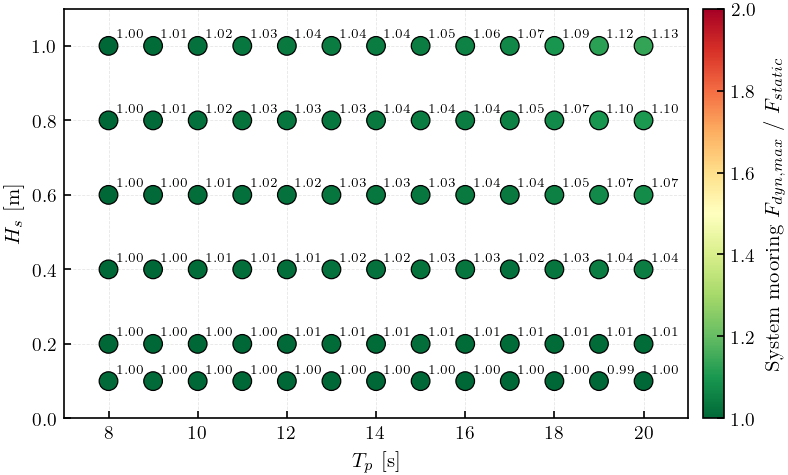

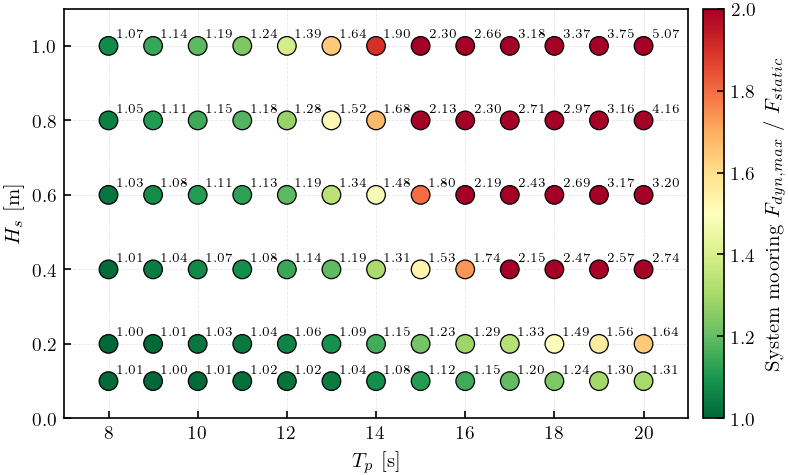

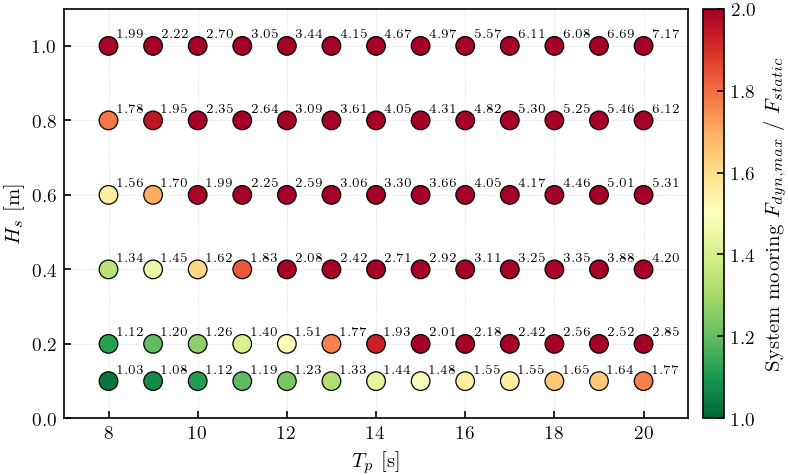

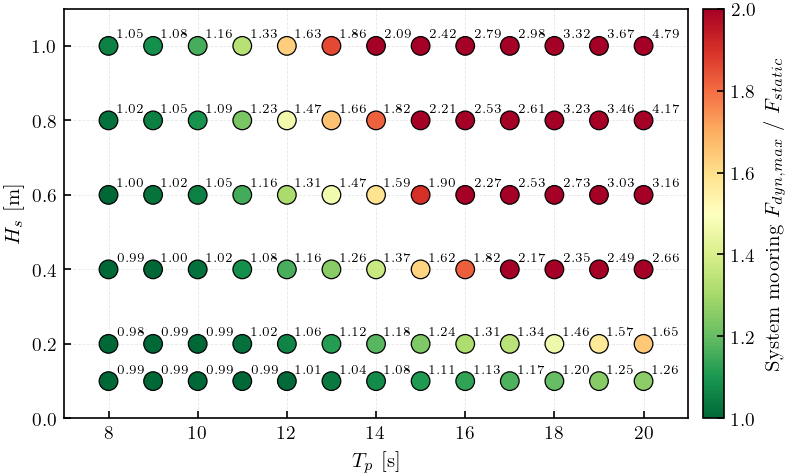

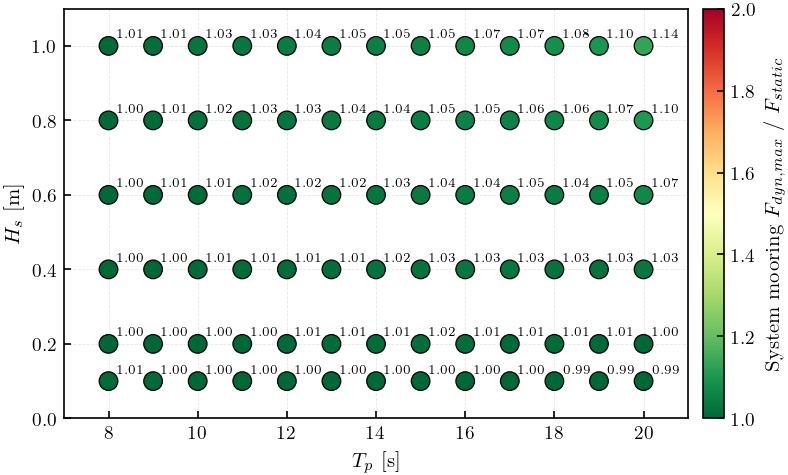

In [5]:
cmap   = plt.cm.RdYlGn_r
norm_m = Normalize(vmin=MOORING_VMIN, vmax=MOORING_VMAX, clip=True)

for h in available:
    df = data[h]
    fig, ax = plt.subplots(figsize=full())
    sc = ax.scatter(df['Tp'], df['Hs'], c=df['mooring_daf_sys'],
                    cmap=cmap, norm=norm_m, s=80, edgecolors='black', linewidths=0.6, zorder=3)
    for _, row in df.iterrows():
        v = row['mooring_daf_sys']
        if not np.isnan(v):
            ax.annotate(f'{v:.2f}', (row['Tp'], row['Hs']),
                        textcoords='offset points', xytext=(4, 4), fontsize=6)
    ax.set_xlabel('$T_p$ [s]')
    ax.set_ylabel('$H_s$ [m]')
    ax.set_xlim(7, 21)
    ax.set_ylim(0.0, 1.1)
    ax.grid(True, alpha=0.3)
    cb = fig.colorbar(sc, ax=ax, pad=0.02)
    cb.set_label(r'System mooring $F_{dyn,max}$ / $F_{static}$')
    plt.tight_layout()
    save(fig, f'daf_swell_mooring_sys_{h}')
    plt.show()

## Mooring DAF — Individual Line

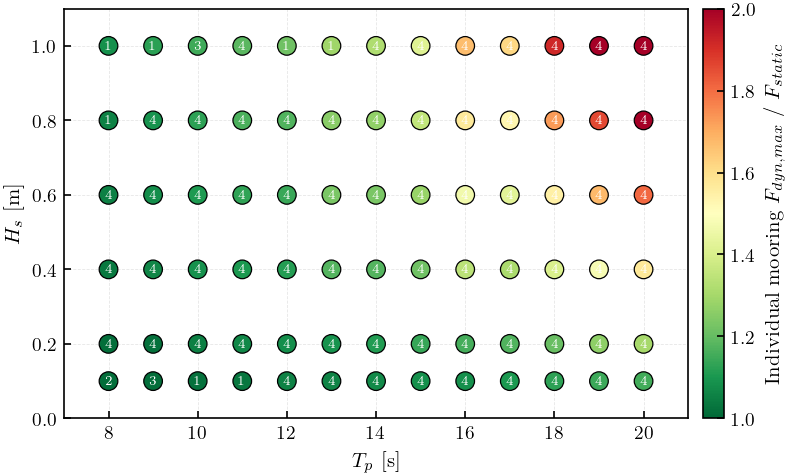

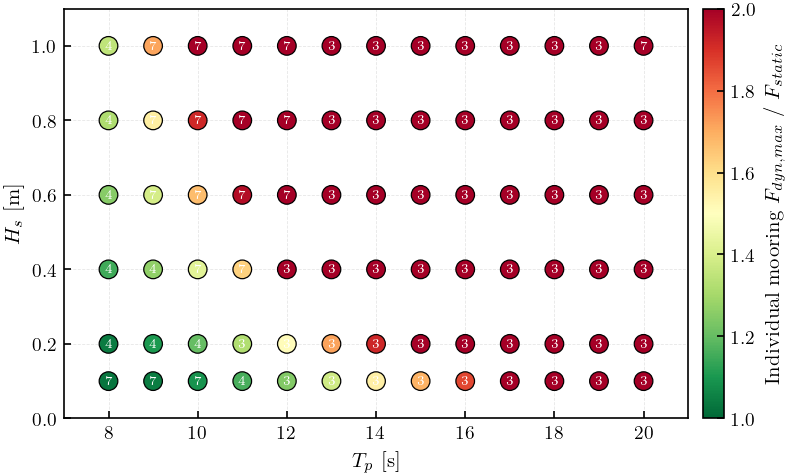

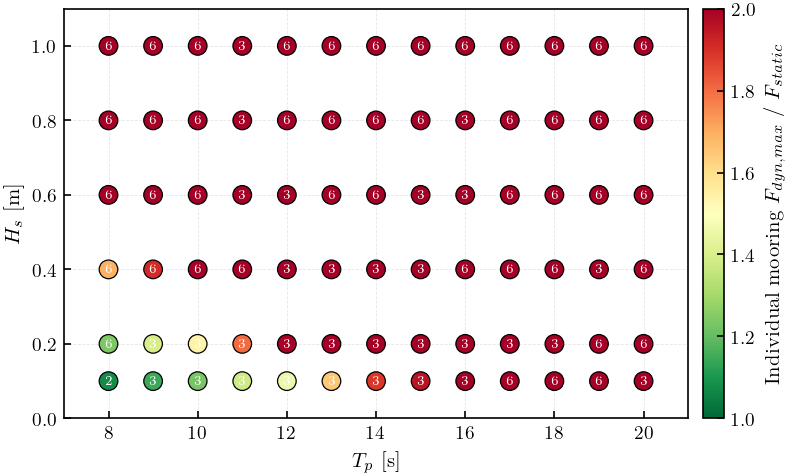

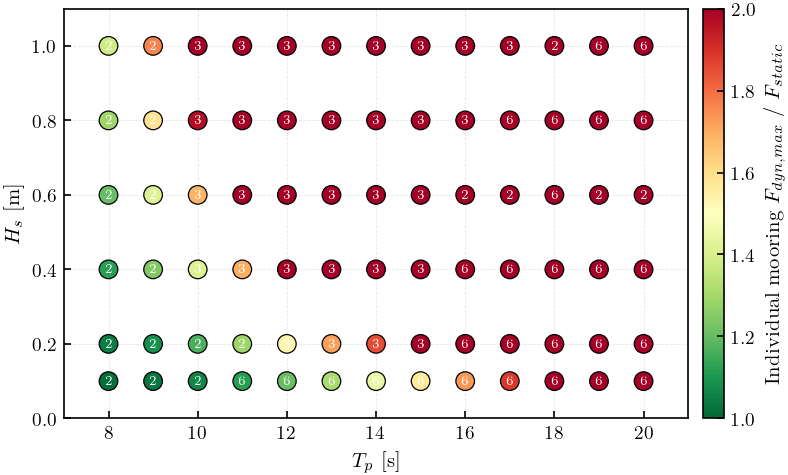

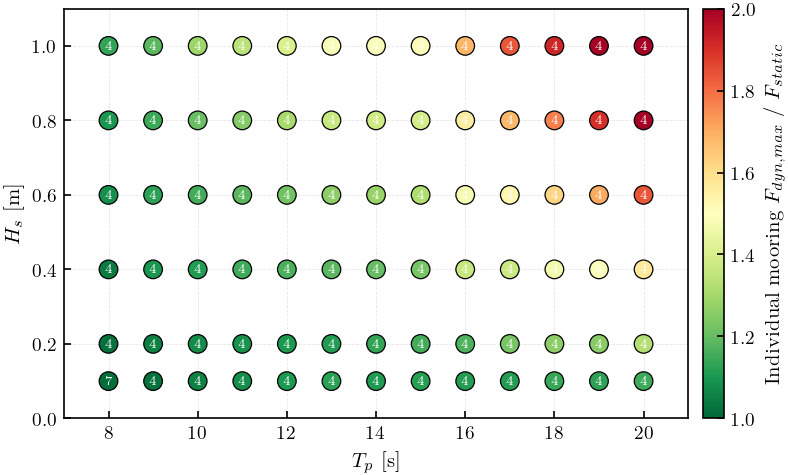

In [6]:
cmap   = plt.cm.RdYlGn_r
norm_m = Normalize(vmin=MOORING_VMIN, vmax=MOORING_VMAX, clip=True)

for h in available:
    df = data[h]
    fig, ax = plt.subplots(figsize=full())
    sc = ax.scatter(df['Tp'], df['Hs'], c=df['mooring_daf_ind'],
                    cmap=cmap, norm=norm_m, s=80, edgecolors='black', linewidths=0.6, zorder=3)
    for _, row in df.iterrows():
        v = row['mooring_daf_ind']
        if not np.isnan(v):
            num = str(row['gov_mooring']).replace('Mooring', '')
            ax.text(row['Tp'], row['Hs'], num, ha='center', va='center',
                    fontsize=6, fontweight='bold', color='white', zorder=6)
    ax.set_xlabel('$T_p$ [s]')
    ax.set_ylabel('$H_s$ [m]')
    ax.set_xlim(7, 21)
    ax.set_ylim(0.0, 1.1)
    ax.grid(True, alpha=0.3)
    cb = fig.colorbar(sc, ax=ax, pad=0.02)
    cb.set_label(r'Individual mooring $F_{dyn,max}$ / $F_{static}$')
    plt.tight_layout()
    save(fig, f'daf_swell_mooring_ind_{h}')
    plt.show()

## Fender DAF — Individual Fender

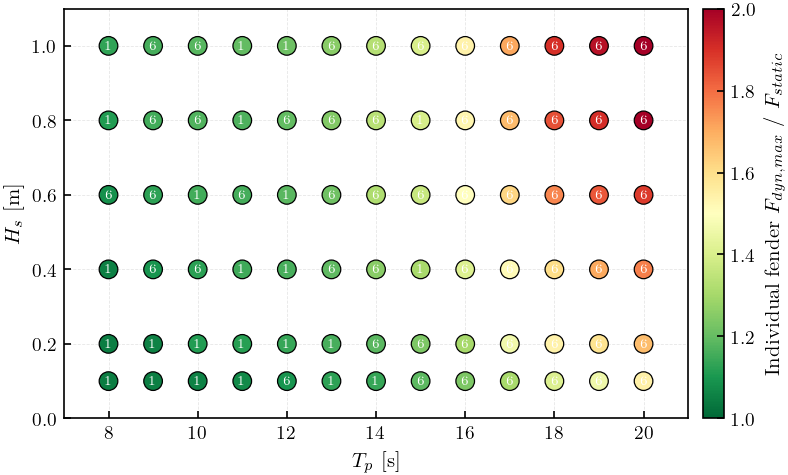

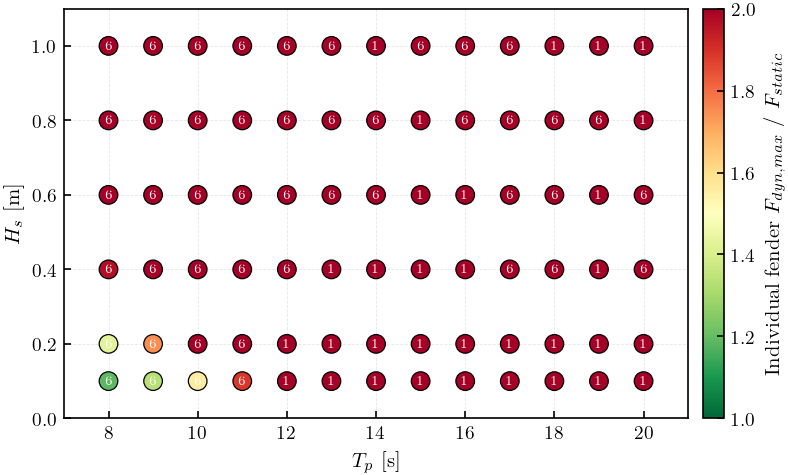

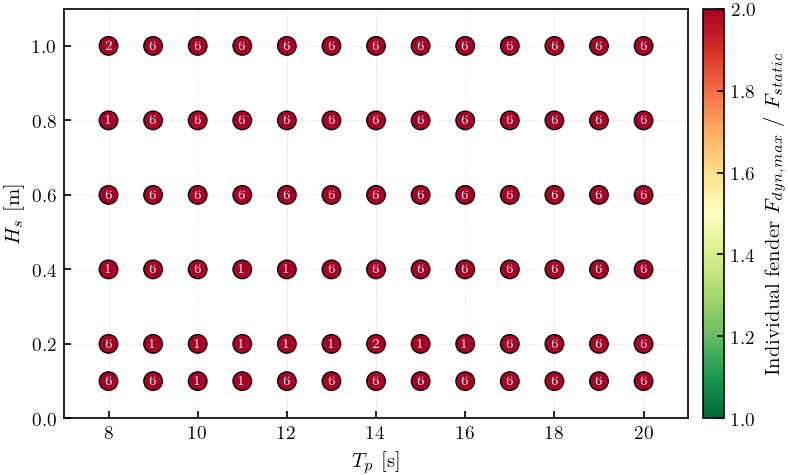

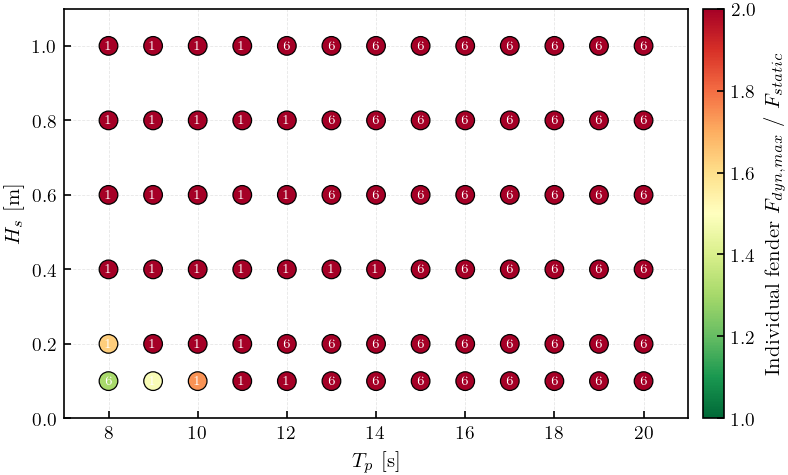

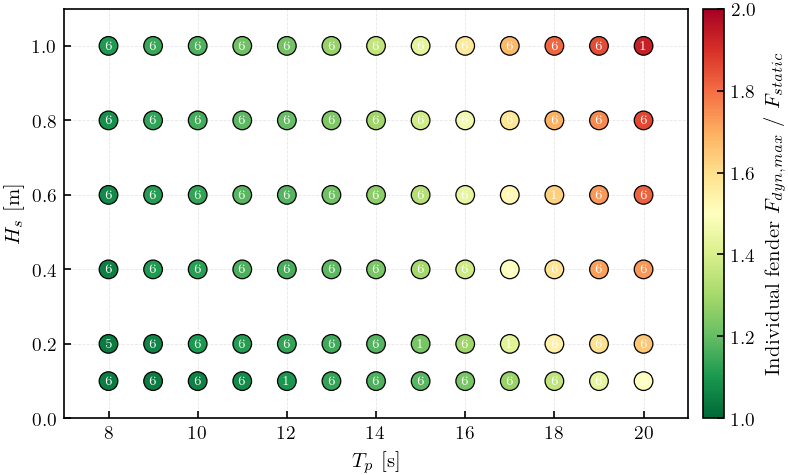

In [7]:
norm_f = Normalize(vmin=FENDER_VMIN, vmax=FENDER_VMAX, clip=True)

for h in available:
    df = data[h]
    fig, ax = plt.subplots(figsize=full())
    sc = ax.scatter(df['Tp'], df['Hs'], c=df['fender_daf_ind'],
                    cmap=cmap, norm=norm_f, s=80, edgecolors='black', linewidths=0.6, zorder=3)
    for _, row in df.iterrows():
        v = row['fender_daf_ind']
        if not np.isnan(v):
            num = str(row['gov_fender']).replace('Fender', '')
            ax.text(row['Tp'], row['Hs'], num, ha='center', va='center',
                    fontsize=6, fontweight='bold', color='white', zorder=6)
    ax.set_xlabel('$T_p$ [s]')
    ax.set_ylabel('$H_s$ [m]')
    ax.set_xlim(7, 21)
    ax.set_ylim(0.0, 1.1)
    ax.grid(True, alpha=0.3)
    cb = fig.colorbar(sc, ax=ax, pad=0.02)
    cb.set_label(r'Individual fender $F_{dyn,max}$ / $F_{static}$')
    plt.tight_layout()
    save(fig, f'daf_swell_fender_ind_{h}')
    plt.show()

## Fender DAF — System

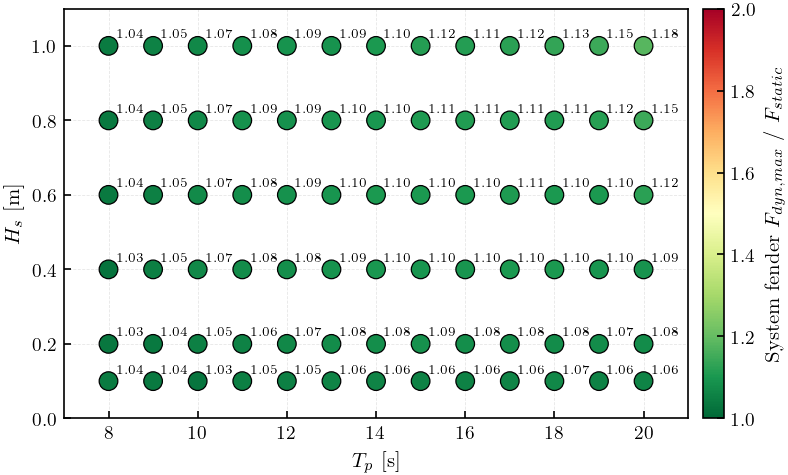

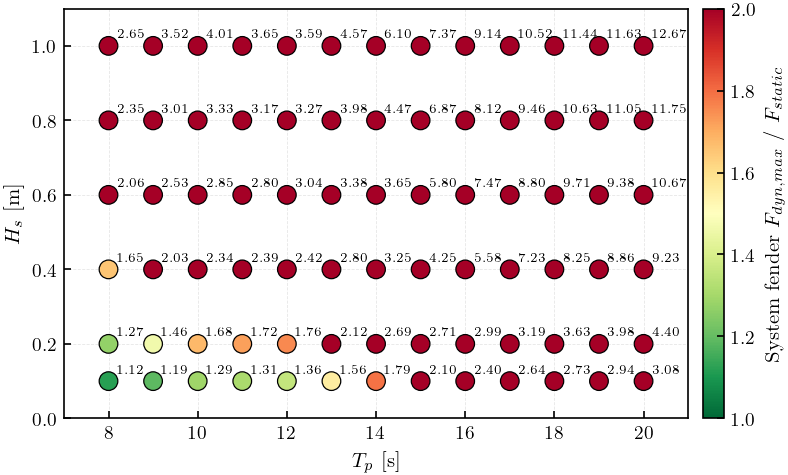

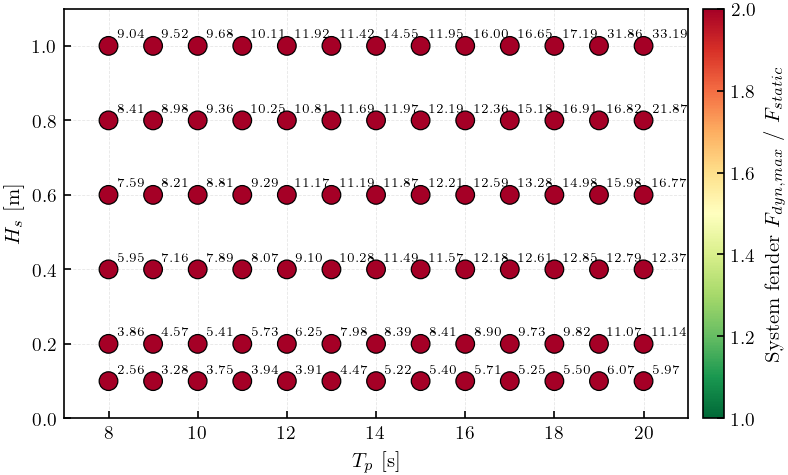

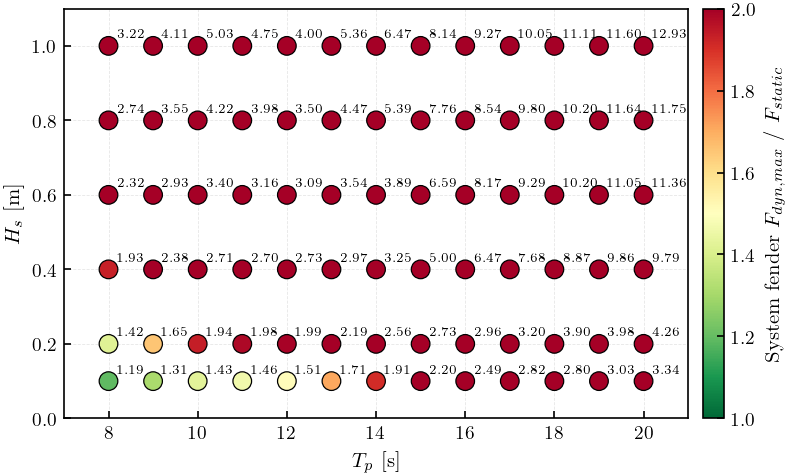

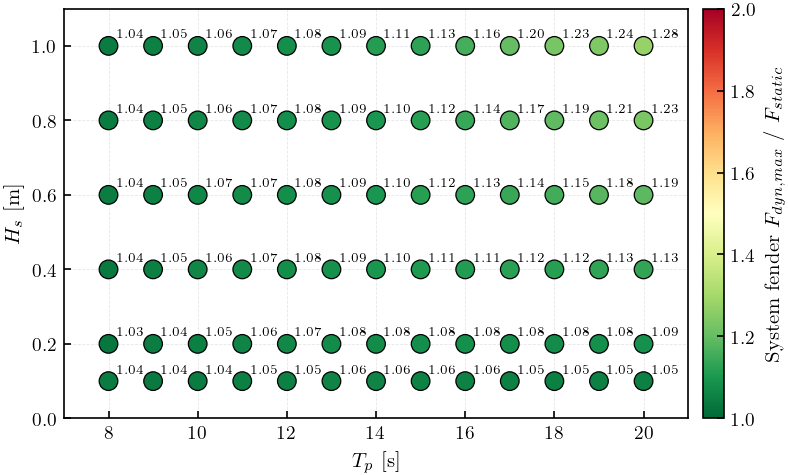

In [8]:
for h in available:
    df = data[h]
    fig, ax = plt.subplots(figsize=full())
    sc = ax.scatter(df['Tp'], df['Hs'], c=df['fender_daf_sys'],
                    cmap=cmap, norm=norm_f, s=80, edgecolors='black', linewidths=0.6, zorder=3)
    for _, row in df.iterrows():
        v = row['fender_daf_sys']
        if not np.isnan(v):
            ax.annotate(f'{v:.2f}', (row['Tp'], row['Hs']),
                        textcoords='offset points', xytext=(4, 4), fontsize=6)
    ax.set_xlabel('$T_p$ [s]')
    ax.set_ylabel('$H_s$ [m]')
    ax.set_xlim(7, 21)
    ax.set_ylim(0.0, 1.1)
    ax.grid(True, alpha=0.3)
    cb = fig.colorbar(sc, ax=ax, pad=0.02)
    cb.set_label(r'System fender $F_{dyn,max}$ / $F_{static}$')
    plt.tight_layout()
    save(fig, f'daf_swell_fender_sys_{h}')
    plt.show()

In [9]:
for h in available:
    df  = data[h]
    cfg = HEADINGS[h]
    print(f'--- Heading {cfg["label"]} ---')
    print(df[['condition', 'Hs', 'Tp',
              'mooring_daf_sys', 'mooring_daf_ind',
              'fender_daf_ind', 'fender_daf_sys']]
          .to_string(index=False, float_format='{:.3f}'.format))
    print()

--- Heading 0° ---
 condition    Hs  Tp  mooring_daf_sys  mooring_daf_ind  fender_daf_ind  fender_daf_sys
         1 0.100   8            1.005            1.013           1.045           1.042
         2 0.100   9            1.004            1.014           1.048           1.037
         3 0.100  10            1.003            1.020           1.055           1.030
         4 0.100  11            0.999            1.035           1.072           1.049
         5 0.100  12            0.998            1.057           1.097           1.054
         6 0.100  13            1.001            1.062           1.127           1.060
         7 0.100  14            0.999            1.071           1.138           1.059
         8 0.100  15            0.999            1.085           1.191           1.057
         9 0.100  16            1.000            1.085           1.237           1.057
        10 0.100  17            0.998            1.102           1.307           1.062
        11 0.100  18    

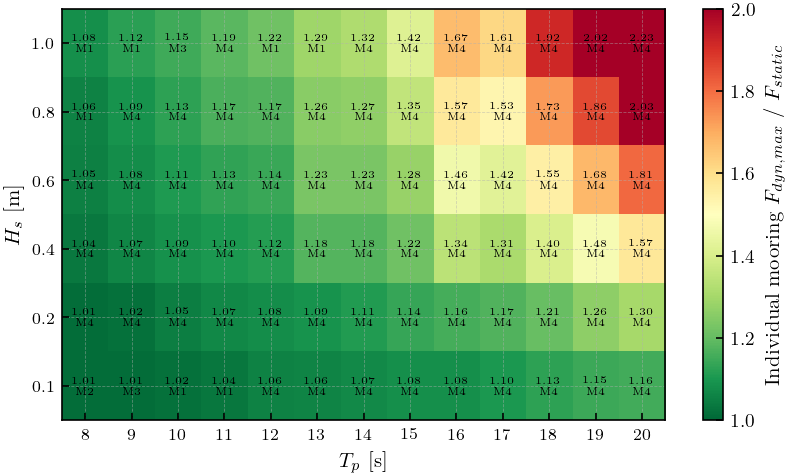

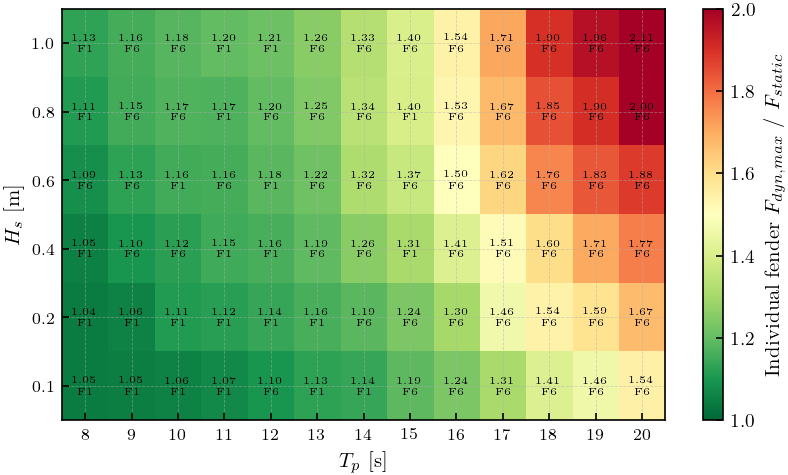

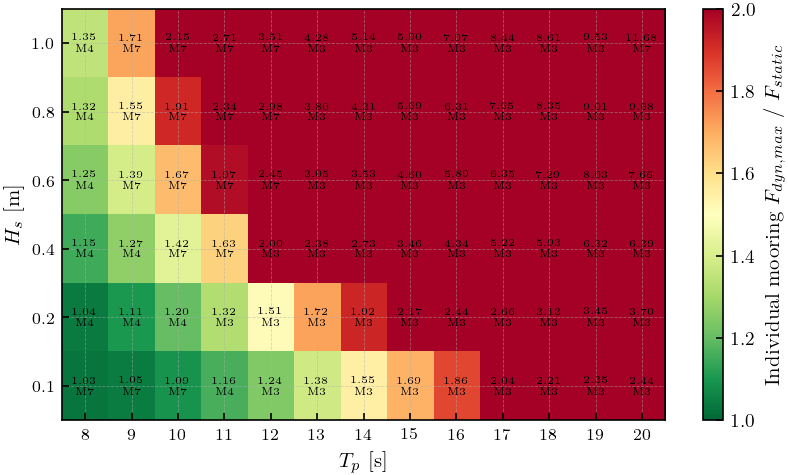

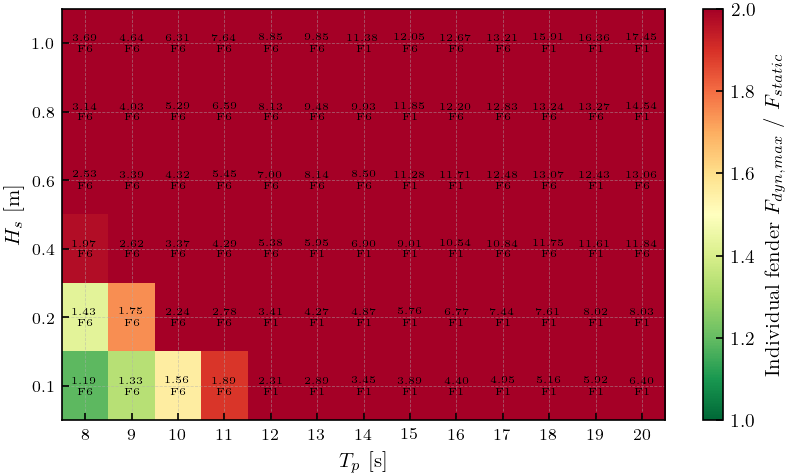

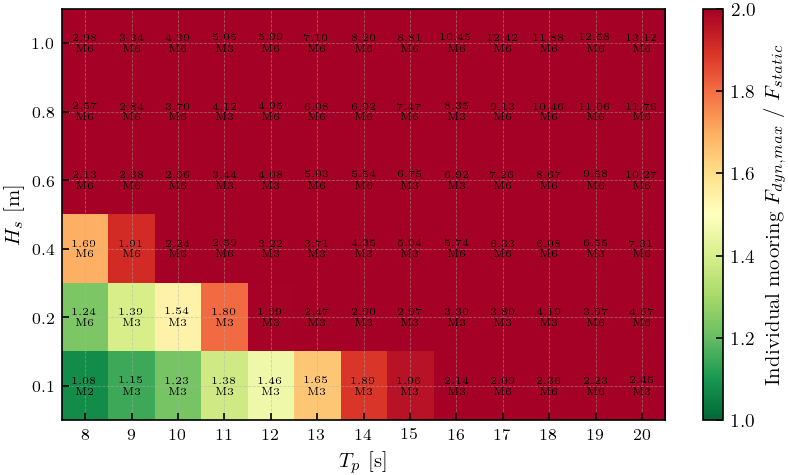

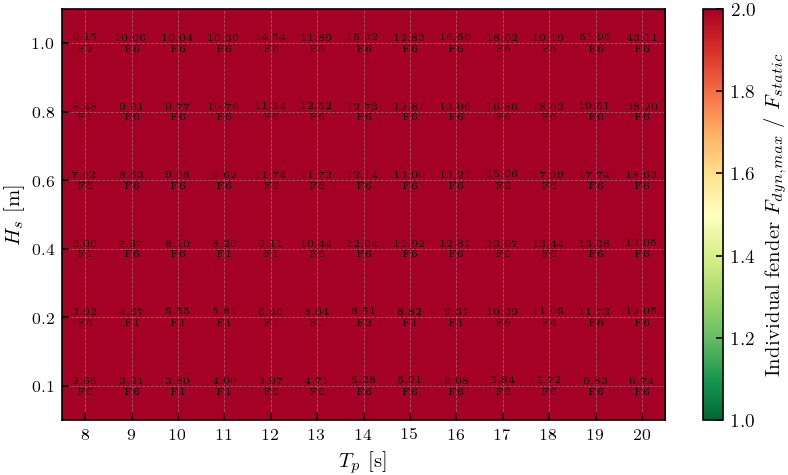

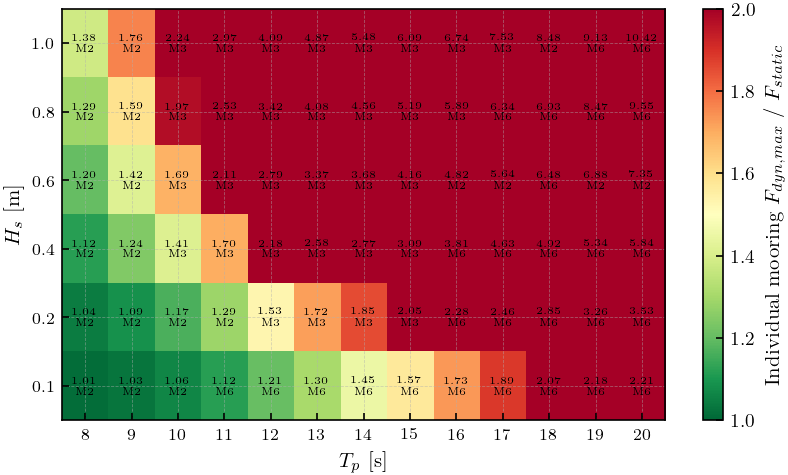

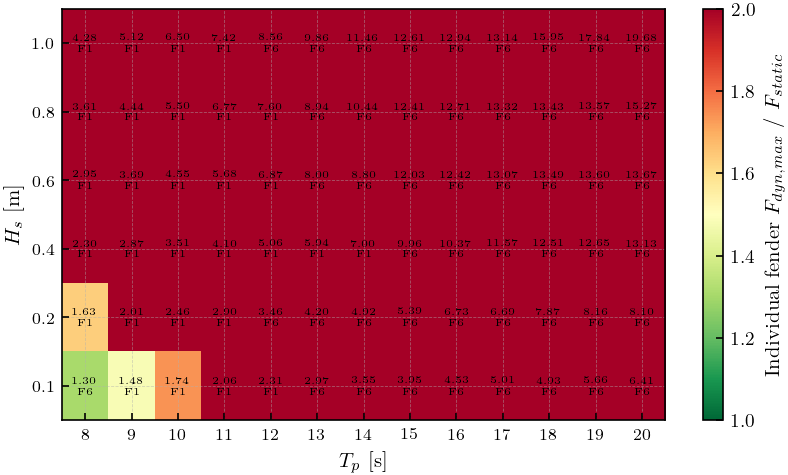

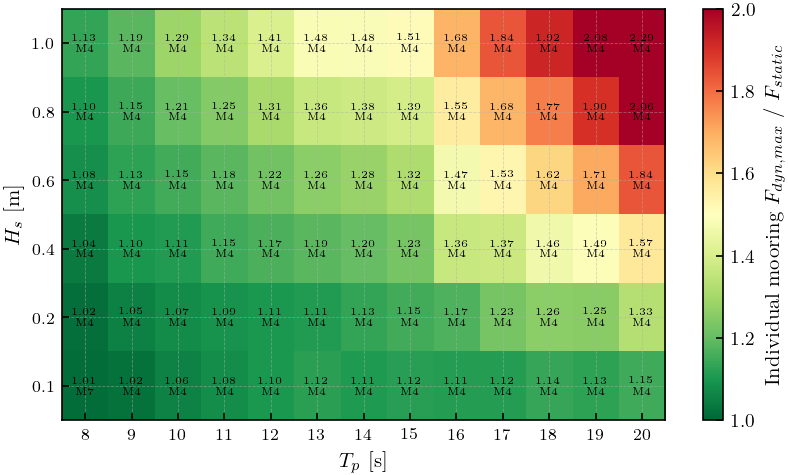

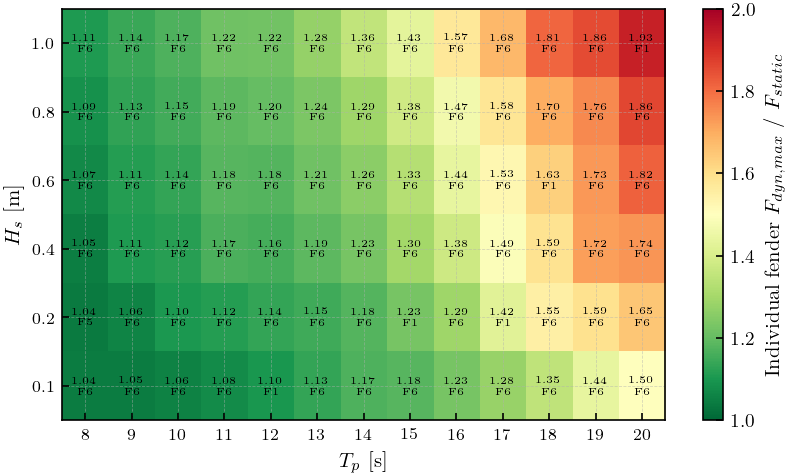

In [10]:
# Individual-element DAF heatmaps on the Hs-Tp grid, one per heading (appendix backing the swell summary table).
# Rows = Hs (0.1 bottom -> 1.0 top), columns = Tp (8 -> 20). Each cell prints the true DAF value with the
# governing element (mooring line M# / fender F#) on the line below; colour saturates at vmax=2.0
# (consistent with the wind-sea heatmaps) but the number does not.
cmap = plt.cm.RdYlGn_r

for h in available:
    df = data[h]
    for col, gov_col, gov_tag, label, prefix in [
        ('mooring_daf_ind', 'gov_mooring', 'Mooring', r'Individual mooring $F_{dyn,max}$ / $F_{static}$', 'daf_swell_mooring_ind_heatmap'),
        ('fender_daf_ind',  'gov_fender',  'Fender',  r'Individual fender $F_{dyn,max}$ / $F_{static}$',  'daf_swell_fender_ind_heatmap'),
    ]:
        mat = np.full((len(HS_VALS), len(TP_VALS)), np.nan)
        ann = np.full((len(HS_VALS), len(TP_VALS)), '', dtype=object)
        for _, row in df.iterrows():
            if pd.isna(row['Hs']) or pd.isna(row['Tp']) or pd.isna(row[col]):
                continue
            r = HS_VALS.index(row['Hs'])
            c = TP_VALS.index(int(row['Tp']))
            mat[r, c] = row[col]
            ann[r, c] = gov_tag[0] + str(row[gov_col]).replace(gov_tag, '')

        fig, ax = plt.subplots(figsize=full())
        im = ax.imshow(mat, aspect='auto', vmin=1.0, vmax=2.0,
                       cmap=cmap, origin='lower', interpolation='none')
        ax.set_xticks(range(len(TP_VALS)))
        ax.set_xticklabels([str(tp) for tp in TP_VALS], fontsize=8)
        ax.set_yticks(range(len(HS_VALS)))
        ax.set_yticklabels([f'{hs:.1f}' for hs in HS_VALS], fontsize=8)
        ax.set_xlabel('$T_p$ [s]')
        ax.set_ylabel('$H_s$ [m]')
        for r in range(len(HS_VALS)):
            for c in range(len(TP_VALS)):
                v = mat[r, c]
                if not np.isnan(v):
                    ax.text(c, r, f'{v:.2f}\n{ann[r, c]}', ha='center', va='center', fontsize=5)
        cb = plt.colorbar(im, ax=ax)
        cb.set_label(label)
        plt.tight_layout()
        save(fig, f'{prefix}_{h}')
        plt.show()